In [1]:
#!/usr/bin/env python3
from __future__ import annotations

import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report


DATASET = "Tobi-Bueck/customer-support-tickets"


def read_idx(path: Path) -> np.ndarray:
    arr = np.loadtxt(path, dtype=np.int64)
    return arr


def md5(s: str) -> str:
    return hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()


def split_df(df: pd.DataFrame, repo_root: Path) -> dict[str, pd.DataFrame]:
    train_idx = read_idx(repo_root / "data" / "train_idx.txt")
    val_idx = read_idx(repo_root / "data" / "val_idx.txt")
    test_idx = read_idx(repo_root / "data" / "test_idx.txt")

    out = {
        "train": df.iloc[train_idx].copy(),
        "val": df.iloc[val_idx].copy(),
        "test": df.iloc[test_idx].copy(),
    }
    return out


def basic_eda(splits: dict[str, pd.DataFrame]) -> None:
    print("\n=== SIZES ===")
    for k, d in splits.items():
        print(f"{k}: {len(d)}")

    print("\n=== MISSING VALUES (share) ===")
    cols = ["subject", "body", "queue", "priority", "type", "language"]
    for k, d in splits.items():
        miss = {c: float(d[c].isna().mean()) if c in d.columns else 1.0 for c in cols}
        print(k, {c: round(miss[c], 4) for c in cols})

    # text lengths
    for k, d in splits.items():
        txt = (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)
        lens = txt.str.len()
        ws_tokens = txt.str.split().map(len)
        print(f"\n=== TEXT LENGTHS ({k}) ===")
        print(f"chars:  mean={lens.mean():.1f}  p50={lens.median():.0f}  p90={lens.quantile(0.9):.0f}  p99={lens.quantile(0.99):.0f}")
        print(f"words:  mean={ws_tokens.mean():.1f}  p50={ws_tokens.median():.0f}  p90={ws_tokens.quantile(0.9):.0f}  p99={ws_tokens.quantile(0.99):.0f}")

    # language dist
    print("\n=== LANGUAGE DISTRIBUTION ===")
    for k, d in splits.items():
        c = d["language"].fillna("NA").value_counts(normalize=True)
        print(k, {i: round(float(v), 4) for i, v in c.items()})

    # class coverage + tails
    for target in ["queue", "priority", "type"]:
        print(f"\n=== CLASS COVERAGE: {target} ===")
        train_labels = set(splits["train"][target].astype(str))
        for k, d in splits.items():
            labels = set(d[target].astype(str))
            missing_vs_train = sorted(list(train_labels - labels))
            print(f"{k}: classes={len(labels)}  missing_vs_train={len(missing_vs_train)}")

        # tail in train
        vc = splits["train"][target].astype(str).value_counts()
        print("train top-10:", list(zip(vc.head(10).index.tolist(), vc.head(10).tolist())))
        print("train bottom-10:", list(zip(vc.tail(10).index.tolist(), vc.tail(10).tolist())))


def duplicate_checks(splits: dict[str, pd.DataFrame]) -> None:
    print("\n=== DUPLICATE TEXT CHECKS (MD5 of subject+body) ===")
    hashes = {}
    for k, d in splits.items():
        txt = (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)
        h = txt.map(md5)
        hashes[k] = set(h.tolist())
        dup_within = 1.0 - (len(hashes[k]) / len(d))
        print(f"{k}: unique={len(hashes[k])}/{len(d)}  within-dup-rate={dup_within:.4f}")

    inter_tv = len(hashes["train"] & hashes["val"])
    inter_tt = len(hashes["train"] & hashes["test"])
    inter_vt = len(hashes["val"] & hashes["test"])
    print(f"cross-dup hashes: train∩val={inter_tv}, train∩test={inter_tt}, val∩test={inter_vt}")

    if inter_tv or inter_tt or inter_vt:
        print("[WARN] Есть одинаковые тексты между сплитами (возможна утечка/слишком похожие письма).")
    else:
        print("[OK] Межсплитовых текстовых дублей не найдено.")


def baseline_tfidf_linear_svm(splits: dict[str, pd.DataFrame]) -> None:
    # Build text
    def make_text(d: pd.DataFrame) -> pd.Series:
        return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)

    X_train = make_text(splits["train"])
    X_test = make_text(splits["test"])

    vec = TfidfVectorizer(
        max_features=200_000,
        ngram_range=(1, 2),
        min_df=2,
    )
    Xtr = vec.fit_transform(X_train)
    Xte = vec.transform(X_test)

    results = {}

    print("\n=== BASELINE: TF-IDF + LinearSVC ===")
    for target in ["queue", "priority", "type"]:
        ytr = splits["train"][target].astype(str).values
        yte = splits["test"][target].astype(str).values

        clf = LinearSVC()
        clf.fit(Xtr, ytr)
        pred = clf.predict(Xte)

        acc = float(accuracy_score(yte, pred))
        if target == "queue":
            mf1 = float(f1_score(yte, pred, average="macro"))
            results["queue_acc"] = acc
            results["queue_macro_f1"] = mf1
            print(f"{target}: acc={acc:.4f}  macro_f1={mf1:.4f}")
        else:
            results[f"{target}_acc"] = acc
            print(f"{target}: acc={acc:.4f}")

    # final score (по вашей формуле)
    score = 0.70 * results["queue_macro_f1"] + 0.15 * results["priority_acc"] + 0.15 * results["type_acc"]
    print("\n=== FINAL SCORE (baseline) ===")
    print(f"Score = {score:.4f}  (0.70*MacroF1(queue) + 0.15*Acc(priority) + 0.15*Acc(type))")


def main():
    repo_root = Path(".").resolve()
    if not (repo_root / "data" / "train_idx.txt").exists():
        raise SystemExit("Запусти из корня репо, где есть папка data/ с *_idx.txt")

    print("Loading dataset:", DATASET)
    ds = load_dataset(DATASET)["train"]
    df = ds.to_pandas()

    # minimal columns check
    needed = {"subject", "body", "queue", "priority", "type", "language"}
    missing = sorted(list(needed - set(df.columns)))
    if missing:
        raise SystemExit(f"Dataset missing columns: {missing}")

    splits = split_df(df, repo_root)

    for k in splits:
        splits[k]["type"] = splits[k]["type"].fillna("Unknown")
    
    basic_eda(splits)
    duplicate_checks(splits)
    baseline_tfidf_linear_svm(splits)

    print("\n[OK] EDA + baseline done.")


if __name__ == "__main__":
    main()

Loading dataset: Tobi-Bueck/customer-support-tickets

=== SIZES ===
train: 49412
val: 6176
test: 6177

=== MISSING VALUES (share) ===
train {'subject': 0.0864, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}
val {'subject': 0.0818, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}
test {'subject': 0.0852, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}

=== TEXT LENGTHS (train) ===
chars:  mean=464.8  p50=460  p90=755  p99=999
words:  mean=62.4  p50=62  p90=99  p99=143

=== TEXT LENGTHS (val) ===
chars:  mean=466.7  p50=463  p90=753  p99=1010
words:  mean=62.7  p50=62  p90=98  p99=142

=== TEXT LENGTHS (test) ===
chars:  mean=460.3  p50=454  p90=751  p99=1015
words:  mean=62.1  p50=62  p90=98  p99=147

=== LANGUAGE DISTRIBUTION ===
train {'de': 0.5424, 'en': 0.4576}
val {'de': 0.5465, 'en': 0.4535}
test {'de': 0.5391, 'en': 0.4609}

=== CLASS COVERAGE: queue ===
train: classes=52  missing_vs_train=0
val: classe

In [2]:
# Датасет почти поровну поделен между немецким и английским. нужно брать мультиязычную модель
# Топ-3 очереди (Technical, Product, Customer Service) забирают львиную долю данных. Хвост из 52 классов очень длинный.
# У 8% тикетов нет заголовка. Значит, при склейке нужно обязательно делать .fillna(''), иначе получим NaN во всем тексте.

In [3]:
import pandas as pd
from datasets import load_dataset
import os

import numpy as np
import pandas as pd
import warnings
import os

# 1. ОТКЛЮЧАЕМ ПРЕДУПРЕЖДЕНИЯ И СНИМАЕМ ЛИМИТЫ
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'
pd.set_option('display.max_columns', None) # Видеть все колонки
pd.set_option('display.expand_frame_repr', False)

In [4]:
# 1. Загружаем датасет с Hugging Face
# Он скачается один раз в кэш и будет подтягиваться оттуда при перезапусках
print("Загрузка датасета...")
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")
df_full = pd.DataFrame(dataset['train']) # В этом датасете всё лежит в 'train'

# 2. Читаем файлы с индексами
# Используем ../ чтобы выйти из папки Notebooks в корень, а затем зайти в data
data_path = "data/"

def load_indices(filename):
    with open(os.path.join(data_path, filename), 'r') as f:
        # Читаем строки, убираем пробелы и превращаем в целые числа
        return [int(line.strip()) for line in f]

print("Загрузка индексов разбиения...")
train_idx = load_indices("train_idx.txt")
val_idx = load_indices("val_idx.txt")
test_idx = load_indices("test_idx.txt")

# 3. Нарезаем данные согласно индексам (iloc берет по позиции строки)
# Мы используем .iloc, так как индексы в файлах соответствуют row_idx исходного датасета
train = df_full.iloc[train_idx].copy()
val = df_full.iloc[val_idx].copy()
test = df_full.iloc[test_idx].copy()

print(f"Готово! Размеры выборок:")
print(f"Train: {len(train)}")
print(f"Val:   {len(val)}")
print(f"Test:  {len(test)}")

# Проверка первых строк
train.head(3)

Загрузка датасета...
Загрузка индексов разбиения...
Готово! Размеры выборок:
Train: 49412
Val:   6176
Test:  6177


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None


Средняя длина текста: 464.52 символов
Медианная длина: 455.00


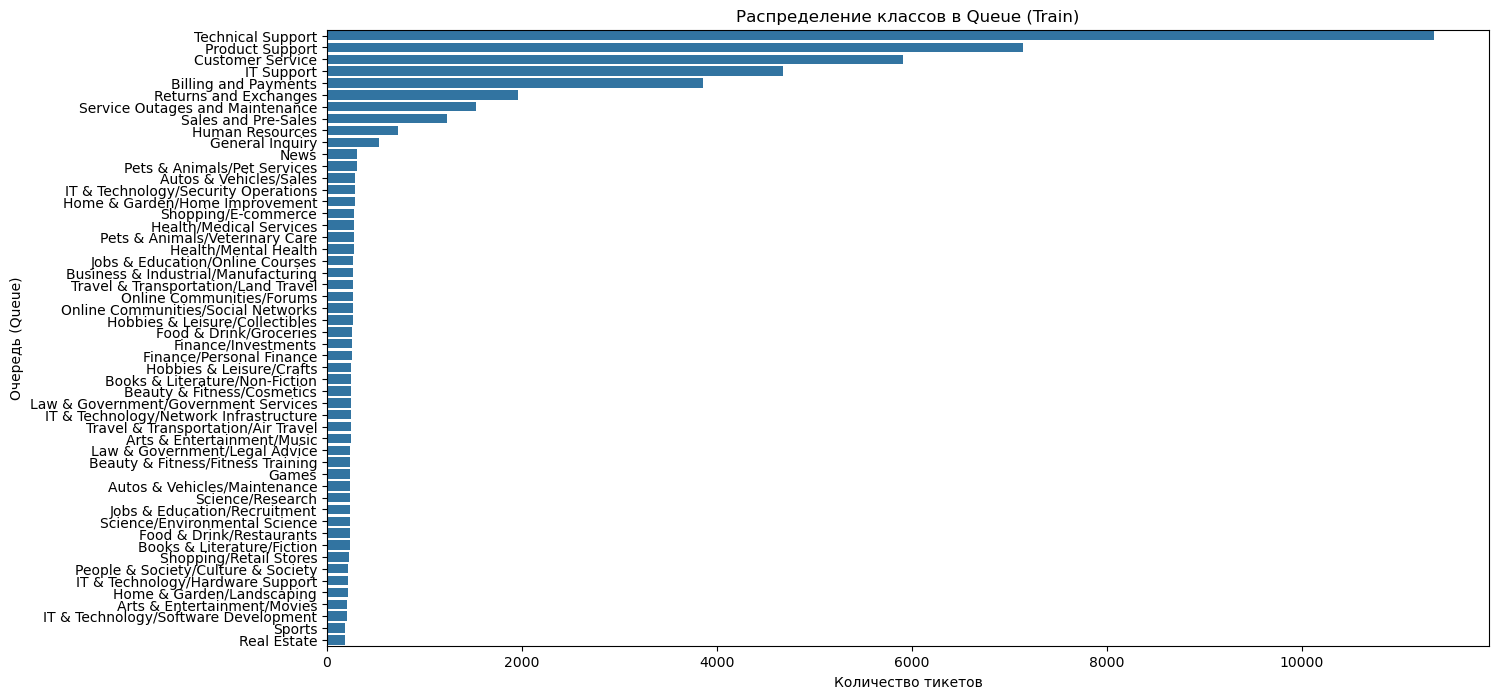

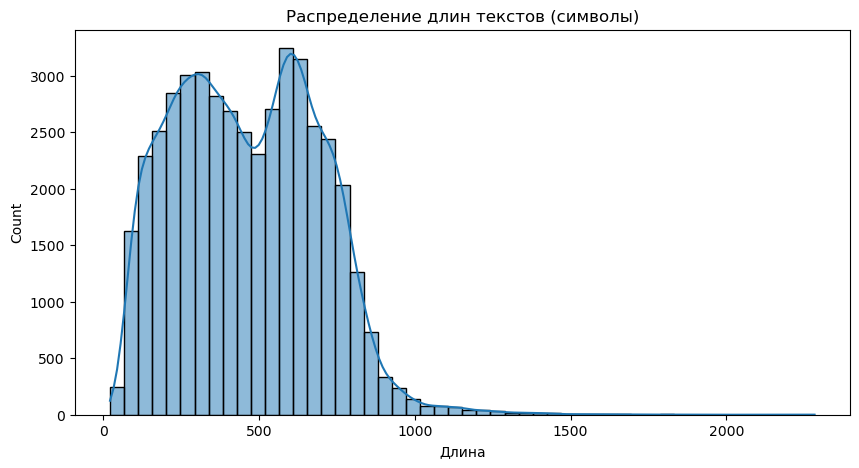

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Объединяем subject и body для анализа длины (как и будет делать модель)
train['text_len'] = train['subject'].str.len() + train['body'].str.len()

print(f"Средняя длина текста: {train['text_len'].mean():.2f} символов")
print(f"Медианная длина: {train['text_len'].median():.2f}")

# 1. Распределение очередей (Queue)
plt.figure(figsize=(15, 8))
sns.countplot(data=train, y='queue', order=train['queue'].value_counts().index)
plt.title('Распределение классов в Queue (Train)')
plt.xlabel('Количество тикетов')
plt.ylabel('Очередь (Queue)')
plt.show()

# 2. Гистограмма длин текстов
plt.figure(figsize=(10, 5))
sns.histplot(train['text_len'], bins=50, kde=True)
plt.title('Распределение длин текстов (символы)')
plt.xlabel('Длина')
plt.show()

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49412 entries, 0 to 61764
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   45144 non-null  object 
 1   body      49410 non-null  object 
 2   answer    38893 non-null  object 
 3   type      38904 non-null  object 
 4   queue     49412 non-null  object 
 5   priority  49412 non-null  object 
 6   language  49412 non-null  object 
 7   version   22924 non-null  float64
 8   tag_1     38904 non-null  object 
 9   tag_2     38857 non-null  object 
 10  tag_3     38722 non-null  object 
 11  tag_4     35212 non-null  object 
 12  tag_5     22118 non-null  object 
 13  tag_6     10580 non-null  object 
 14  tag_7     4757 non-null   object 
 15  tag_8     1981 non-null   object 
 16  text_len  45142 non-null  float64
dtypes: float64(2), object(15)
memory usage: 6.8+ MB


In [15]:
# Примерный расчет (грубый)
train['token_count'] = train['combined_text'].apply(lambda x: len(x.split()))
print(train['token_count'].describe())

count    49412.000000
mean        62.445438
std         31.205693
min          1.000000
25%         37.000000
50%         62.000000
75%         87.000000
max        283.000000
Name: token_count, dtype: float64


In [16]:
# ну для берта 256 норм

# LabelEncoder

In [7]:
from sklearn.preprocessing import LabelEncoder

# 1. Объединяем текст (Subject + Body)
# Используем заполнитель для NaN, чтобы не потерять данные
def preprocess_text(df):
    # Важно: добавляем разделитель [SEP] или просто перенос строки, 
    # чтобы модель понимала, где кончается заголовок
    return (df['subject'].fillna("") + " " + df['body'].fillna("")).astype(str)

for df in [train, val, test]:
    df['combined_text'] = preprocess_text(df)

# 2. Кодируем таргеты (у нас их три!)
# Нам важно сохранить энкодеры, чтобы потом расшифровать предсказания
target_cols = ['queue', 'priority', 'type']
encoders = {col: LabelEncoder() for col in target_cols}

for col in target_cols:
    # Обучаем только на train, чтобы избежать утечки
    train[f'{col}_label'] = encoders[col].fit_transform(train[col].astype(str))
    # Для val и test только трансформируем
    val[f'{col}_label'] = encoders[col].transform(val[col].astype(str))
    test[f'{col}_label'] = encoders[col].transform(test[col].astype(str))

# Выведем количество классов для проверки (нужно для настройки "голов" BERT)
num_classes = {col: len(encoders[col].classes_) for col in target_cols}
print("Количество классов по задачам:", num_classes)
print("\nПример обработанного текста:")
print(train['combined_text'].iloc[0][:150] + "...")

Количество классов по задачам: {'queue': 52, 'priority': 5, 'type': 5}

Пример обработанного текста:
Wesentlicher Sicherheitsvorfall Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Kompon...


# Солянка быстрых моделей

In [8]:
from gensim.models import Word2Vec, FastText
from gensim.utils import simple_preprocess
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

# --- 2. ПРЕДОБРАБОТКА ---
print("Токенизация текстов...")
train_tokens = train['combined_text'].apply(simple_preprocess)
test_tokens = test['combined_text'].apply(simple_preprocess)

# --- 3. ГЕНЕРАЦИЯ ФИЧЕЙ (EMBEDDINGS) ---
def get_mean_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

print("Обучение эмбеддингов (это может занять пару минут)...")
w2v_sg = Word2Vec(sentences=train_tokens, vector_size=100, sg=1, window=5, min_count=2, workers=4)
w2v_cbow = Word2Vec(sentences=train_tokens, vector_size=100, sg=0, window=5, min_count=2, workers=4)
ft_model = FastText(sentences=train_tokens, vector_size=100, window=5, min_count=2, workers=4)

feature_sets = {
    "TF-IDF": None, # Считаем отдельно ниже
    "W2V_SkipGram": (
        np.array([get_mean_vector(t, w2v_sg) for t in train_tokens]),
        np.array([get_mean_vector(t, w2v_sg) for t in test_tokens])
    ),
    "W2V_CBOW": (
        np.array([get_mean_vector(t, w2v_cbow) for t in train_tokens]),
        np.array([get_mean_vector(t, w2v_cbow) for t in test_tokens])
    ),
    "FastText": (
        np.array([get_mean_vector(t, ft_model) for t in train_tokens]),
        np.array([get_mean_vector(t, ft_model) for t in test_tokens])
    )
}

# TF-IDF отдельно (разреженная матрица)
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
feature_sets["TF-IDF"] = (
    tfidf.fit_transform(train['combined_text']),
    tfidf.transform(test['combined_text'])
)

# --- 4. СРАВНИТЕЛЬНЫЙ ЦИКЛ С КАСТОМНЫМ СКОРИНГОМ ---
models_to_test = {
    "SVM": lambda: LinearSVC(max_iter=1500, random_state=42),
    "LogReg": lambda: LogisticRegression(solver='liblinear', random_state=42)
}

targets = ["queue", "priority", "type"]
final_results = []

for f_name, (X_tr, X_te) in feature_sets.items():
    for m_name, model_init in models_to_test.items():
        print(f"Эксперимент: {f_name} + {m_name}")
        
        metrics = {}
        # Обучаем модель на каждую из 3 задач
        for target in targets:
            clf = model_init()
            y_tr = train[f"{target}_label"]
            y_te = test[f"{target}_label"]
            
            clf.fit(X_tr, y_tr)
            preds = clf.predict(X_te)
            
            if target == "queue":
                metrics["mf1_queue"] = f1_score(y_te, preds, average='macro')
                metrics["acc_queue"] = accuracy_score(y_te, preds)
            else:
                metrics[f"acc_{target}"] = accuracy_score(y_te, preds)
        
        # Считаем кастомный Score по формуле препода
        custom_score = (0.70 * metrics["mf1_queue"] + 
                        0.15 * metrics["acc_priority"] + 
                        0.15 * metrics["acc_type"])
        
        final_results.append({
            "Features": f_name,
            "Model": m_name,
            "Final_Score": round(custom_score, 4),
            "MacroF1_Queue": round(metrics["mf1_queue"], 4),
            "Acc_Priority": round(metrics["acc_priority"], 4),
            "Acc_Type": round(metrics["acc_type"], 4)
        })

# --- 5. ВЫВОД РЕЗУЛЬТАТОВ ---
report_df = pd.DataFrame(final_results).sort_values(by="Final_Score", ascending=False)
print("\n=== СРАВНИТЕЛЬНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ ===")
print(report_df)

Токенизация текстов...
Обучение эмбеддингов (это может занять пару минут)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Эксперимент: TF-IDF + SVM
Эксперимент: TF-IDF + LogReg
Эксперимент: W2V_SkipGram + SVM
Эксперимент: W2V_SkipGram + LogReg
Эксперимент: W2V_CBOW + SVM
Эксперимент: W2V_CBOW + LogReg
Эксперимент: FastText + SVM
Эксперимент: FastText + LogReg

=== СРАВНИТЕЛЬНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ ===
       Features   Model  Final_Score  MacroF1_Queue  Acc_Priority  Acc_Type
0        TF-IDF     SVM       0.7932         0.8115        0.6286    0.8723
1        TF-IDF  LogReg       0.6792         0.6576        0.5990    0.8603
2  W2V_SkipGram     SVM       0.4553         0.3648        0.5130    0.8195
3  W2V_SkipGram  LogReg       0.4174         0.3116        0.5095    0.8190
7      FastText  LogReg       0.3603         0.2417        0.4761    0.7978
5      W2V_CBOW  LogReg       0.3469         0.2193        0.4816    0.8073
6      FastText     SVM       0.3438         0.2187        0.4763    0.7950
4      W2V_CBOW     SVM       0.3348         0.2026        0.4803    0.8059


In [9]:
X_train_text = (train["subject"].fillna("") + "\n\n" + train["body"].fillna("")).astype(str)
X_test_text = (test["subject"].fillna("") + "\n\n" + test["body"].fillna("")).astype(str)

# 2. Мощный TF-IDF (без предварительной токенизации через simple_preprocess)
# Даем векторизатору самому рубить текст на части
tfidf_final = TfidfVectorizer(
    max_features=250000, 
    ngram_range=(1, 2), 
    min_df=2
)

X_train_final = tfidf_final.fit_transform(X_train_text)
X_test_final = tfidf_final.transform(X_test_text)

# 3. Обучаем SVM (самый сильный в твоей таблице)
clf = LinearSVC(max_iter=2000, random_state=42)
clf.fit(X_train_final, train["queue_label"])
preds = clf.predict(X_test_final)

# Считаем только для Queue, чтобы проверить теорию
print(f"Новый Macro-F1 (Queue): {f1_score(test['queue_label'], preds, average='macro'):.4f}")

Новый Macro-F1 (Queue): 0.8942


In [12]:
X_train_text = (train["subject"].fillna("") + "\n\n" + train["body"].fillna("")).astype(str)
X_test_text = (test["subject"].fillna("") + "\n\n" + test["body"].fillna("")).astype(str)

# 2. Мощный TF-IDF (без предварительной токенизации через simple_preprocess)
# Даем векторизатору самому рубить текст на части
tfidf_final = TfidfVectorizer(
    max_features=300000, 
    ngram_range=(1, 4), 
    min_df=2
)

X_train_final = tfidf_final.fit_transform(X_train_text)
X_test_final = tfidf_final.transform(X_test_text)

# 3. Обучаем SVM (самый сильный в твоей таблице)
clf = LinearSVC(max_iter=2000, random_state=42)
clf.fit(X_train_final, train["queue_label"])
preds = clf.predict(X_test_final)

# Считаем только для Queue, чтобы проверить теорию
print(f"Новый Macro-F1 (Queue): {f1_score(test['queue_label'], preds, average='macro'):.4f}")

Новый Macro-F1 (Queue): 0.8769


In [13]:
X_train_final

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8144779 stored elements and shape (49412, 300000)>

# Пробуем посмотреть где ошибается бейзлайн

Loading dataset: Tobi-Bueck/customer-support-tickets

=== SIZES ===
train: 49412
val: 6176
test: 6177

=== MISSING VALUES (share) ===
train {'subject': 0.0864, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}
val {'subject': 0.0818, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}
test {'subject': 0.0852, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}

=== TEXT LENGTHS (train) ===
chars:  mean=464.8  p50=460  p90=755  p99=999
words:  mean=62.4  p50=62  p90=99  p99=143

=== TEXT LENGTHS (val) ===
chars:  mean=466.7  p50=463  p90=753  p99=1010
words:  mean=62.7  p50=62  p90=98  p99=142

=== TEXT LENGTHS (test) ===
chars:  mean=460.3  p50=454  p90=751  p99=1015
words:  mean=62.1  p50=62  p90=98  p99=147

=== LANGUAGE DISTRIBUTION ===
train {'de': 0.5424, 'en': 0.4576}
val {'de': 0.5465, 'en': 0.4535}
test {'de': 0.5391, 'en': 0.4609}

=== CLASS COVERAGE: queue ===
train: classes=52  missing_vs_train=0
val: classe

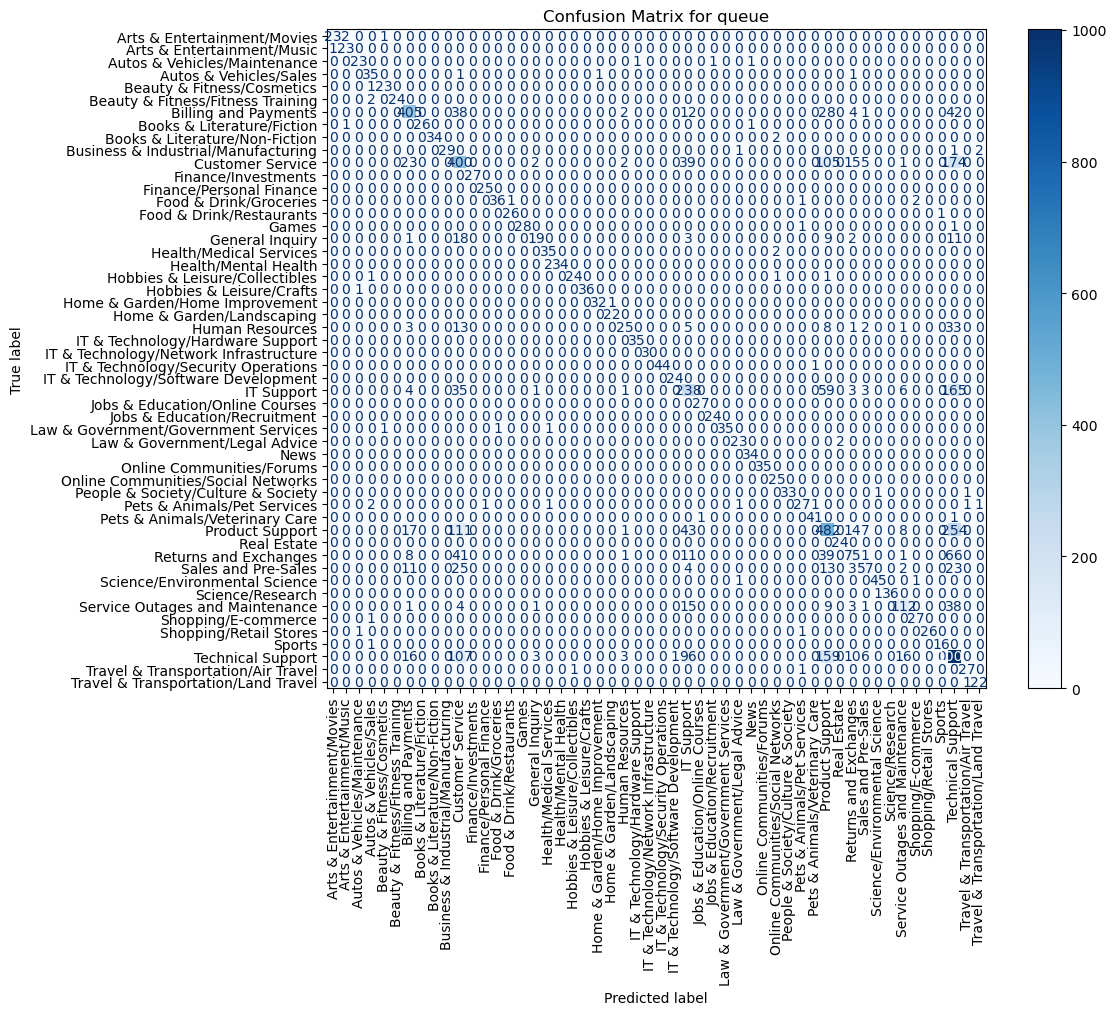


[OK] EDA + baseline + error analysis done.


In [3]:
#!/usr/bin/env python3
from __future__ import annotations

import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report


DATASET = "Tobi-Bueck/customer-support-tickets"


def read_idx(path: Path) -> np.ndarray:
    arr = np.loadtxt(path, dtype=np.int64)
    return arr


def md5(s: str) -> str:
    return hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()


def split_df(df: pd.DataFrame, repo_root: Path) -> dict[str, pd.DataFrame]:
    train_idx = read_idx(repo_root / "data" / "train_idx.txt")
    val_idx = read_idx(repo_root / "data" / "val_idx.txt")
    test_idx = read_idx(repo_root / "data" / "test_idx.txt")

    out = {
        "train": df.iloc[train_idx].copy(),
        "val": df.iloc[val_idx].copy(),
        "test": df.iloc[test_idx].copy(),
    }
    return out


def basic_eda(splits: dict[str, pd.DataFrame]) -> None:
    print("\n=== SIZES ===")
    for k, d in splits.items():
        print(f"{k}: {len(d)}")

    print("\n=== MISSING VALUES (share) ===")
    cols = ["subject", "body", "queue", "priority", "type", "language"]
    for k, d in splits.items():
        miss = {c: float(d[c].isna().mean()) if c in d.columns else 1.0 for c in cols}
        print(k, {c: round(miss[c], 4) for c in cols})

    # text lengths
    for k, d in splits.items():
        txt = (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)
        lens = txt.str.len()
        ws_tokens = txt.str.split().map(len)
        print(f"\n=== TEXT LENGTHS ({k}) ===")
        print(f"chars:  mean={lens.mean():.1f}  p50={lens.median():.0f}  p90={lens.quantile(0.9):.0f}  p99={lens.quantile(0.99):.0f}")
        print(f"words:  mean={ws_tokens.mean():.1f}  p50={ws_tokens.median():.0f}  p90={ws_tokens.quantile(0.9):.0f}  p99={ws_tokens.quantile(0.99):.0f}")

    # language dist
    print("\n=== LANGUAGE DISTRIBUTION ===")
    for k, d in splits.items():
        c = d["language"].fillna("NA").value_counts(normalize=True)
        print(k, {i: round(float(v), 4) for i, v in c.items()})

    # class coverage + tails
    for target in ["queue", "priority", "type"]:
        print(f"\n=== CLASS COVERAGE: {target} ===")
        train_labels = set(splits["train"][target].astype(str))
        for k, d in splits.items():
            labels = set(d[target].astype(str))
            missing_vs_train = sorted(list(train_labels - labels))
            print(f"{k}: classes={len(labels)}  missing_vs_train={len(missing_vs_train)}")

        # tail in train
        vc = splits["train"][target].astype(str).value_counts()
        print("train top-10:", list(zip(vc.head(10).index.tolist(), vc.head(10).tolist())))
        print("train bottom-10:", list(zip(vc.tail(10).index.tolist(), vc.tail(10).tolist())))


def duplicate_checks(splits: dict[str, pd.DataFrame]) -> None:
    print("\n=== DUPLICATE TEXT CHECKS (MD5 of subject+body) ===")
    hashes = {}
    for k, d in splits.items():
        txt = (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)
        h = txt.map(md5)
        hashes[k] = set(h.tolist())
        dup_within = 1.0 - (len(hashes[k]) / len(d))
        print(f"{k}: unique={len(hashes[k])}/{len(d)}  within-dup-rate={dup_within:.4f}")

    inter_tv = len(hashes["train"] & hashes["val"])
    inter_tt = len(hashes["train"] & hashes["test"])
    inter_vt = len(hashes["val"] & hashes["test"])
    print(f"cross-dup hashes: train∩val={inter_tv}, train∩test={inter_tt}, val∩test={inter_vt}")

    if inter_tv or inter_tt or inter_vt:
        print("[WARN] Есть одинаковые тексты между сплитами (возможна утечка/слишком похожие письма).")
    else:
        print("[OK] Межсплитовых текстовых дублей не найдено.")


def baseline_tfidf_linear_svm(splits: dict[str, pd.DataFrame]) -> None:
    # Build text
    def make_text(d: pd.DataFrame) -> pd.Series:
        return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)

    X_train = make_text(splits["train"])
    X_test = make_text(splits["test"])

    vec = TfidfVectorizer(
        max_features=200_000,
        ngram_range=(1, 2),
        min_df=2,
    )
    Xtr = vec.fit_transform(X_train)
    Xte = vec.transform(X_test)

    results = {}

    print("\n=== BASELINE: TF-IDF + LinearSVC ===")
    for target in ["queue", "priority", "type"]:
        ytr = splits["train"][target].astype(str).values
        yte = splits["test"][target].astype(str).values

        clf = LinearSVC()
        clf.fit(Xtr, ytr)
        pred = clf.predict(Xte)

        acc = float(accuracy_score(yte, pred))
        if target == "queue":
            mf1 = float(f1_score(yte, pred, average="macro"))
            results["queue_acc"] = acc
            results["queue_macro_f1"] = mf1
            print(f"{target}: acc={acc:.4f}  macro_f1={mf1:.4f}")
        else:
            results[f"{target}_acc"] = acc
            print(f"{target}: acc={acc:.4f}")

    # final score (по вашей формуле)
    score = 0.70 * results["queue_macro_f1"] + 0.15 * results["priority_acc"] + 0.15 * results["type_acc"]
    print("\n=== FINAL SCORE (baseline) ===")
    print(f"Score = {score:.4f}  (0.70*MacroF1(queue) + 0.15*Acc(priority) + 0.15*Acc(type))")

def analyze_errors(splits, vec, target="queue", n_samples=10):
    # Готовим данные
    X_train = (splits["train"]["subject"].fillna("") + "\n\n" + splits["train"]["body"].fillna("")).astype(str)
    X_test = (splits["test"]["subject"].fillna("") + "\n\n" + splits["test"]["body"].fillna("")).astype(str)
    
    y_train = splits["train"][target].astype(str).values
    y_test = splits["test"][target].astype(str).values
    
    # Обучаем модель заново (или передай обученную)
    Xtr = vec.fit_transform(X_train)
    Xte = vec.transform(X_test)
    
    clf = LinearSVC(max_iter=10000)
    clf.fit(Xtr, y_train)
    
    # Делаем предсказания
    preds = clf.predict(Xte)
    
    # Находим индексы ошибок
    error_mask = preds != y_test
    errors_df = splits["test"][error_mask].copy()
    errors_df['predicted'] = preds[error_mask]
    errors_df['actual'] = y_test[error_mask]
    errors_df['full_text'] = X_test[error_mask].values

    print(f"\n=== TOP {n_samples} ERRORS FOR {target.upper()} ===")
    
    # Выводим первые несколько ошибок для глаза
    for i, row in errors_df.head(n_samples).iterrows():
        print(f"--- Error Sample ---")
        print(f"ACTUAL:    {row['actual']}")
        print(f"PREDICTED: {row['predicted']}")
        print(f"TEXT:      {row['full_text'][:200]}...") # Показываем начало текста
        print("-" * 30)
    
    return errors_df

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion(splits, vec, target="queue"):
    X_train = (splits["train"]["subject"].fillna("") + "\n\n" + splits["train"]["body"].fillna("")).astype(str)
    X_test = (splits["test"]["subject"].fillna("") + "\n\n" + splits["test"]["body"].fillna("")).astype(str)
    
    y_train = splits["train"][target].astype(str).values
    y_test = splits["test"][target].astype(str).values
    
    Xtr = vec.fit_transform(X_train)
    Xte = vec.transform(X_test)
    
    clf = LinearSVC(max_iter=10000)
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)

    cm = confusion_matrix(y_test, pred, labels=clf.classes_)
    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
    disp.plot(xticks_rotation='vertical', ax=ax, cmap='Blues')
    plt.title(f"Confusion Matrix for {target}")
    plt.tight_layout()
    plt.show()

def main():
    repo_root = Path(".").resolve()
    if not (repo_root / "data" / "train_idx.txt").exists():
        raise SystemExit("Запусти из корня репо, где есть папка data/ с *_idx.txt")

    print("Loading dataset:", DATASET)
    ds = load_dataset(DATASET)["train"]
    df = ds.to_pandas()

    # minimal columns check
    needed = {"subject", "body", "queue", "priority", "type", "language"}
    missing = sorted(list(needed - set(df.columns)))
    if missing:
        raise SystemExit(f"Dataset missing columns: {missing}")

    splits = split_df(df, repo_root)

    for k in splits:
        splits[k]["type"] = splits[k]["type"].fillna("Unknown")
    
    basic_eda(splits)
    duplicate_checks(splits)
    baseline_tfidf_linear_svm(splits)

# --- НОВОЕ: АНАЛИЗ ОШИБОК ---
    # Создаем векторайзер для анализа (можно чуть проще, чем в бейзлайне для скорости)
    analysis_vec = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)

    # 1. Смотрим конкретные примеры ошибок в "queue"
    errors_df = analyze_errors(splits, analysis_vec, target="queue", n_samples=5)

    # 2. Строим матрицу ошибок (Confusion Matrix)
    # ВАЖНО: В Colab/Jupyter это выведет картинку, в обычном скрипте откроет окно
    plot_confusion(splits, analysis_vec, target="queue")

    print("\n[OK] EDA + baseline + error analysis done.")
if __name__ == "__main__":
    main()

# Взять лог рег как следующее решение после бейзлайна

Загрузка датасета...

=== ОБУЧЕНИЕ BASELINE (Logistic Regression) ===


C:\Users\MadBoss\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\MadBoss\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\MadBoss\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Базовый Score на тесте (100% данных): 0.7516

=== ТОП-5 УВЕРЕННЫХ ОШИБОК МОДЕЛИ ===
                                              subject            queue  \
16962                     Problem with Software Crash  Product Support   
46936                            Event of Data Breach  Product Support   
10649        Problem with Analytics Dashboard Display       IT Support   
48663  Problem with Analytics Dashboard Visualization       IT Support   
12450  Problem with Analytics Dashboard Visualization       IT Support   

              queue_pred  queue_conf  
16962  Technical Support    0.820084  
46936  Technical Support    0.813647  
10649  Technical Support    0.774879  
48663  Technical Support    0.756486  
12450  Technical Support    0.756486  


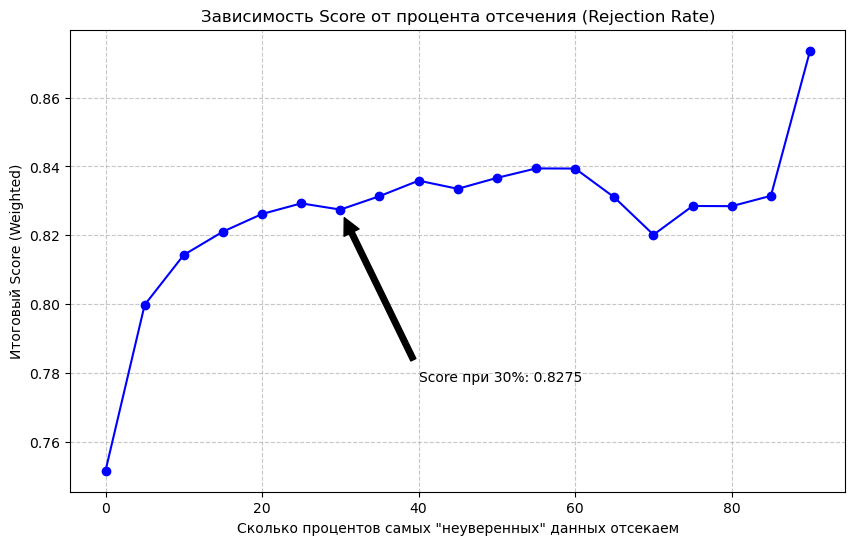

In [5]:
#!/usr/bin/env python3
from __future__ import annotations

import hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

DATASET = "Tobi-Bueck/customer-support-tickets"

def read_idx(path: Path) -> np.ndarray:
    return np.loadtxt(path, dtype=np.int64)

def md5(s: str) -> str:
    return hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()

def split_df(df: pd.DataFrame, repo_root: Path) -> dict[str, pd.DataFrame]:
    train_idx = read_idx(repo_root / "data" / "train_idx.txt")
    val_idx = read_idx(repo_root / "data" / "val_idx.txt")
    test_idx = read_idx(repo_root / "data" / "test_idx.txt")
    return {
        "train": df.iloc[train_idx].copy(),
        "val": df.iloc[val_idx].copy(),
        "test": df.iloc[test_idx].copy(),
    }

def baseline_tfidf_analysis(splits: dict[str, pd.DataFrame]) -> dict[str, pd.DataFrame]:
    def make_text(d: pd.DataFrame) -> pd.Series:
        return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)

    X_train_text = make_text(splits["train"])
    vec = TfidfVectorizer(max_features=100_000, ngram_range=(1, 2), min_df=2)
    X_train = vec.fit_transform(X_train_text)

    processed_splits = {k: v.copy() for k, v in splits.items()}

    print("\n=== ОБУЧЕНИЕ BASELINE (Logistic Regression) ===")
    
    for target in ["queue", "priority", "type"]:
        y_train = splits["train"][target].astype(str).values
        clf = LogisticRegression(max_iter=1000, multi_class='multinomial')
        clf.fit(X_train, y_train)

        for name, df in processed_splits.items():
            X_text = make_text(df)
            X_features = vec.transform(X_text)
            
            probs = clf.predict_proba(X_features)
            preds = clf.classes_[np.argmax(probs, axis=1)]
            confidences = np.max(probs, axis=1)

            df[f"{target}_pred"] = preds
            df[f"{target}_conf"] = confidences
            df[f"{target}_is_correct"] = (df[target].astype(str) == preds)

    return processed_splits

def plot_rejection_curve(df):
    """Строит график зависимости финального Score от % отброшенных данных"""
    percents = np.arange(0, 95, 5)
    scores = []
    
    for p in percents:
        threshold = np.percentile(df['queue_conf'], p)
        subset = df[df['queue_conf'] >= threshold]
        
        m_f1_q = f1_score(subset['queue'].astype(str), subset['queue_pred'], average='macro')
        acc_p = accuracy_score(subset['priority'].astype(str), subset['priority_pred'])
        acc_t = accuracy_score(subset['type'].astype(str), subset['type_pred'])
        
        final_score = 0.70 * m_f1_q + 0.15 * acc_p + 0.15 * acc_t
        scores.append(final_score)

    plt.figure(figsize=(10, 6))
    plt.plot(percents, scores, marker='o', linestyle='-', color='b')
    plt.title('Зависимость Score от процента отсечения (Rejection Rate)')
    plt.xlabel('Сколько процентов самых "неуверенных" данных отсекаем')
    plt.ylabel('Итоговый Score (Weighted)')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Отмечаем точку 30%
    idx_30 = list(percents).index(30)
    plt.annotate(f'Score при 30%: {scores[idx_30]:.4f}', 
                 xy=(30, scores[idx_30]), xytext=(40, scores[idx_30]-0.05),
                 arrowprops=dict(facecolor='black', shrink=0.05))
    
    plt.show()

def main():
    repo_root = Path(".").resolve()
    if not (repo_root / "data" / "train_idx.txt").exists():
        raise SystemExit("Запусти из корня репо, где есть папка data/ с *_idx.txt")

    print("Загрузка датасета...")
    ds = load_dataset(DATASET)["train"]
    df = ds.to_pandas()
    
    # Заполнение пропусков
    for col in ["subject", "body", "type"]:
        df[col] = df[col].fillna("Unknown")

    splits = split_df(df, repo_root)
    
    # Прогон модели
    processed_splits = baseline_tfidf_analysis(splits)
    test_results = processed_splits['test']

    # 1. Считаем базовый скор (0% отсечения)
    m_f1_q = f1_score(test_results['queue'].astype(str), test_results['queue_pred'], average='macro')
    acc_p = accuracy_score(test_results['priority'].astype(str), test_results['priority_pred'])
    acc_t = accuracy_score(test_results['type'].astype(str), test_results['type_pred'])
    base_score = 0.70 * m_f1_q + 0.15 * acc_p + 0.15 * acc_t
    
    print(f"\nБазовый Score на тесте (100% данных): {base_score:.4f}")

    # 2. Самые уверенные ошибки
    print("\n=== ТОП-5 УВЕРЕННЫХ ОШИБОК МОДЕЛИ ===")
    errors = test_results[test_results['queue_is_correct'] == False].sort_values('queue_conf', ascending=False)
    print(errors[['subject', 'queue', 'queue_pred', 'queue_conf']].head(5))

    # 3. Строим график
    
    plot_rejection_curve(test_results)

    # Сохраняем результаты
    test_results.to_csv("full_results_with_predictions.csv", index=False)
    print("\n[OK] Все данные с метками сохранены в full_results_with_predictions.csv")

if __name__ == "__main__":
    main()

видим что скор хорошо поднимается, хотя кривую хотелось бы видеть монотонную \
Кстати в такой конфигурации и с лог регом можно и процентов 5-10 отсечь и качество хорошо поднимается

# Оптуна для лог рега

In [8]:
#!/usr/bin/env python3
from __future__ import annotations

import hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

DATASET = "Tobi-Bueck/customer-support-tickets"

def read_idx(path: Path) -> np.ndarray:
    return np.loadtxt(path, dtype=np.int64)

def md5(s: str) -> str:
    return hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()

def split_df(df: pd.DataFrame, repo_root: Path) -> dict[str, pd.DataFrame]:
    train_idx = read_idx(repo_root / "data" / "train_idx.txt")
    val_idx = read_idx(repo_root / "data" / "val_idx.txt")
    test_idx = read_idx(repo_root / "data" / "test_idx.txt")
    return {
        "train": df.iloc[train_idx].copy(),
        "val": df.iloc[val_idx].copy(),
        "test": df.iloc[test_idx].copy(),
    }

def baseline_tfidf_tuned(splits: dict[str, pd.DataFrame]) -> dict[str, pd.DataFrame]:
    def make_text(d: pd.DataFrame) -> pd.Series:
        return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)

    train_text = make_text(splits["train"])
    val_text = make_text(splits["val"])
    
    # Немного снизим количество признаков для скорости тюнинга (на финальное качество влияет слабо)
    vec = TfidfVectorizer(max_features=50_000, ngram_range=(1, 2), min_df=3)
    X_train = vec.fit_transform(train_text)
    X_val = vec.transform(val_text)

    targets = ["queue", "priority", "type"]
    y_train_dict = {t: splits["train"][t].astype(str).values for t in targets}
    y_val_dict = {t: splits["val"][t].astype(str).values for t in targets}

    def objective(trial):
        c_param = trial.suggest_float("C", 0.1, 10.0, log=True)
        use_balanced = trial.suggest_categorical("balanced", [True, False])
        cw = "balanced" if use_balanced else None
        
        scores = {}
        for t in targets:
            # Смена солвера на lbfgs даст огромный буст в скорости
            clf = LogisticRegression(
                C=c_param, 
                class_weight=cw, 
                max_iter=500, # 500 обычно хватает для сходимости lbfgs
                solver="lbfgs", 
                n_jobs=1, # Важно! Убираем мультипоточность отсюда
                random_state=42
            )
            clf.fit(X_train, y_train_dict[t])
            preds = clf.predict(X_val)
            
            if t == "queue":
                scores[t] = f1_score(y_val_dict[t], preds, average="macro")
            else:
                scores[t] = accuracy_score(y_val_dict[t], preds)
        
        return 0.70 * scores["queue"] + 0.15 * scores["priority"] + 0.15 * scores["type"]

    print("\n=== ЗАПУСК OPTUNA (Ускоренный режим) ===")
    study = optuna.create_study(direction="maximize")
    # Теперь Optuna будет крутить испытания быстрее
    study.optimize(objective, timeout=60*3, n_jobs=-1)
    
    print("\n=== ЛУЧШИЕ ГИПЕРПАРАМЕТРЫ ===")
    print(study.best_params)
    print(f"Лучший Score на валидации: {study.best_value:.4f}")

    # Обучаем финальную модель на лучших параметрах
    best_c = study.best_params["C"]
    best_cw = "balanced" if study.best_params["balanced"] else None
    
    processed_splits = {k: v.copy() for k, v in splits.items()}
    
    for t in targets:
        final_clf = LogisticRegression(C=best_c, class_weight=best_cw, max_iter=2000, solver="lbfgs", n_jobs=-1, random_state=42)
        final_clf.fit(X_train, y_train_dict[t])
        
        for name, df in processed_splits.items():
            X_feat = vec.transform(make_text(df))
            probs = final_clf.predict_proba(X_feat)
            df[f"{t}_pred"] = final_clf.classes_[np.argmax(probs, axis=1)]
            df[f"{t}_conf"] = np.max(probs, axis=1)
            df[f"{t}_is_correct"] = (df[t].astype(str) == df[f"{t}_pred"])

    return processed_splits

def plot_rejection_curve(df):
    percents = np.arange(0, 95, 5)
    scores = []
    for p in percents:
        threshold = np.percentile(df['queue_conf'], p)
        subset = df[df['queue_conf'] >= threshold]
        m_f1_q = f1_score(subset['queue'].astype(str), subset['queue_pred'], average='macro')
        acc_p = accuracy_score(subset['priority'].astype(str), subset['priority_pred'])
        acc_t = accuracy_score(subset['type'].astype(str), subset['type_pred'])
        scores.append(0.70 * m_f1_q + 0.15 * acc_p + 0.15 * acc_t)

    plt.figure(figsize=(10, 6))
    plt.plot(percents, scores, marker='o', color='b')
    plt.title('Score vs Rejection Rate (Optuna Optimized)')
    plt.xlabel('Rejection Percentile')
    plt.ylabel('Custom Score')
    plt.grid(True)
    plt.show()

def main():
    repo_root = Path(".").resolve()
    if not (repo_root / "data" / "train_idx.txt").exists():
        raise SystemExit("Запусти из корня репо, где есть папка data/ с *_idx.txt")

    print("Загрузка датасета...")
    ds = load_dataset(DATASET)["train"]
    df = ds.to_pandas()
    for col in ["subject", "body", "type"]:
        df[col] = df[col].fillna("Unknown")

    splits = split_df(df, repo_root)
    
    # Запуск тюнинга и предсказания
    processed_splits = baseline_tfidf_tuned(splits)
    test_results = processed_splits['test']

    m_f1_q = f1_score(test_results['queue'].astype(str), test_results['queue_pred'], average='macro')
    acc_p = accuracy_score(test_results['priority'].astype(str), test_results['priority_pred'])
    acc_t = accuracy_score(test_results['type'].astype(str), test_results['type_pred'])
    print(f"\nFinal Score on Test (Optuna): {0.70 * m_f1_q + 0.15 * acc_p + 0.15 * acc_t:.4f}")

    print("\n=== ТОП-5 УВЕРЕННЫХ ОШИБОК (QUEUE) ===")
    errors = test_results[test_results['queue_is_correct'] == False].sort_values('queue_conf', ascending=False)
    print(errors[['subject', 'queue', 'queue_pred', 'queue_conf']].head(5))

    plot_rejection_curve(test_results)
    test_results.to_csv("optuna_results.csv", index=False)

if __name__ == "__main__":
    main()

Загрузка датасета...


[I 2026-03-14 18:36:54,435] A new study created in memory with name: no-name-be613c35-5f43-4fbf-8672-e720bbed5296



=== ЗАПУСК OPTUNA (Ускоренный режим) ===


[I 2026-03-14 18:45:11,577] Trial 4 finished with value: 0.6423426977959501 and parameters: {'C': 0.12178751001357294, 'balanced': True}. Best is trial 4 with value: 0.6423426977959501.
[I 2026-03-14 18:45:38,093] Trial 8 finished with value: 0.6371649066881679 and parameters: {'C': 0.10829571022615853, 'balanced': True}. Best is trial 4 with value: 0.6423426977959501.
[I 2026-03-14 18:46:17,058] Trial 7 finished with value: 0.6721015188481027 and parameters: {'C': 0.17643664793305955, 'balanced': True}. Best is trial 7 with value: 0.6721015188481027.
[I 2026-03-14 18:46:28,573] Trial 9 finished with value: 0.6691974983935011 and parameters: {'C': 0.16800553735287363, 'balanced': True}. Best is trial 7 with value: 0.6721015188481027.
[I 2026-03-14 18:46:47,404] Trial 10 finished with value: 0.685247646967077 and parameters: {'C': 0.20218012657824191, 'balanced': True}. Best is trial 10 with value: 0.685247646967077.
[I 2026-03-14 18:47:56,221] Trial 3 finished with value: 0.70933128103

KeyboardInterrupt: 

Загрузка датасета...

=== ОБУЧЕНИЕ BASELINE (LogReg | C=4.22 | Weights=balanced) ===

ФИНАЛЬНЫЙ Score на тесте (100% данных): 0.8300
Detail: Queue MacroF1=0.8544, Priority Acc=0.6618, Type Acc=0.8844

=== ТОП-5 УВЕРЕННЫХ ОШИБОК (QUEUE) ===
                                                 subject              queue  \
3573                    Issue with SaaS Platform Service    Product Support   
17235               Assistance with Service Interruption    Product Support   
18335  Significant Service Interruption Impacting Dig...  Technical Support   
16217  Inquiry About Data Analytics Solutions for Inv...    Product Support   
61750  Inquiry About Data Analytics Solutions for Inv...    Product Support   

                            queue_pred  queue_conf  
3573   Service Outages and Maintenance    0.885219  
17235  Service Outages and Maintenance    0.864187  
18335  Service Outages and Maintenance    0.818553  
16217              Sales and Pre-Sales    0.777390  
61750              S

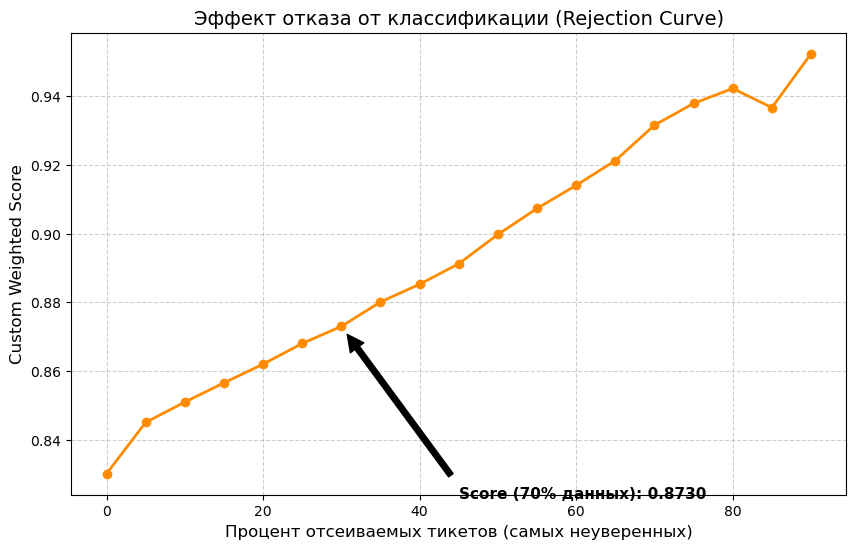


[OK] Результаты сохранены в final_baseline_results.csv


In [9]:
#!/usr/bin/env python3
from __future__ import annotations

import hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

DATASET = "Tobi-Bueck/customer-support-tickets"

def read_idx(path: Path) -> np.ndarray:
    return np.loadtxt(path, dtype=np.int64)

def md5(s: str) -> str:
    return hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()

def split_df(df: pd.DataFrame, repo_root: Path) -> dict[str, pd.DataFrame]:
    train_idx = read_idx(repo_root / "data" / "train_idx.txt")
    val_idx = read_idx(repo_root / "data" / "val_idx.txt")
    test_idx = read_idx(repo_root / "data" / "test_idx.txt")
    return {
        "train": df.iloc[train_idx].copy(),
        "val": df.iloc[val_idx].copy(),
        "test": df.iloc[test_idx].copy(),
    }

def baseline_tfidf_analysis(splits: dict[str, pd.DataFrame]) -> dict[str, pd.DataFrame]:
    def make_text(d: pd.DataFrame) -> pd.Series:
        return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)

    # Используем 100k признаков, как в оригинале
    X_train_text = make_text(splits["train"])
    vec = TfidfVectorizer(max_features=100_000, ngram_range=(1, 2), min_df=2)
    X_train = vec.fit_transform(X_train_text)

    processed_splits = {k: v.copy() for k, v in splits.items()}

    # Внедряем лучшие ГП из Optuna
    BEST_C = 4.222488576523903
    BEST_CW = "balanced"

    print(f"\n=== ОБУЧЕНИЕ BASELINE (LogReg | C={BEST_C:.2f} | Weights={BEST_CW}) ===")
    
    for target in ["queue", "priority", "type"]:
        y_train = splits["train"][target].astype(str).values
        
        # lbfgs быстрее saga и отлично справляется с L2 регуляризацией
        clf = LogisticRegression(
            C=BEST_C, 
            class_weight=BEST_CW, 
            max_iter=1000, 
            solver='lbfgs', 
            n_jobs=-1
        )
        clf.fit(X_train, y_train)

        for name, df in processed_splits.items():
            X_text = make_text(df)
            X_features = vec.transform(X_text)
            
            probs = clf.predict_proba(X_features)
            preds = clf.classes_[np.argmax(probs, axis=1)]
            confidences = np.max(probs, axis=1)

            df[f"{target}_pred"] = preds
            df[f"{target}_conf"] = confidences
            df[f"{target}_is_correct"] = (df[target].astype(str) == preds)

    return processed_splits

def plot_rejection_curve(df):
    """Строит график зависимости финального Score от % отброшенных данных"""
    percents = np.arange(0, 95, 5)
    scores = []
    
    for p in percents:
        # Считаем порог по уверенности в основной задаче - queue
        threshold = np.percentile(df['queue_conf'], p)
        subset = df[df['queue_conf'] >= threshold]
        
        if len(subset) == 0:
            scores.append(0)
            continue

        m_f1_q = f1_score(subset['queue'].astype(str), subset['queue_pred'], average='macro')
        acc_p = accuracy_score(subset['priority'].astype(str), subset['priority_pred'])
        acc_t = accuracy_score(subset['type'].astype(str), subset['type_pred'])
        
        final_score = 0.70 * m_f1_q + 0.15 * acc_p + 0.15 * acc_t
        scores.append(final_score)

    plt.figure(figsize=(10, 6))
    plt.plot(percents, scores, marker='o', linestyle='-', color='darkorange', linewidth=2)
    plt.title('Эффект отказа от классификации (Rejection Curve)', fontsize=14)
    plt.xlabel('Процент отсеиваемых тикетов (самых неуверенных)', fontsize=12)
    plt.ylabel('Custom Weighted Score', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Поиск значения на 30%
    idx_30 = list(percents).index(30)
    plt.annotate(f'Score (70% данных): {scores[idx_30]:.4f}', 
                 xy=(30, scores[idx_30]), xytext=(45, scores[idx_30]-0.05),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=11, fontweight='bold')
    
    plt.show()

def main():
    repo_root = Path(".").resolve()
    if not (repo_root / "data" / "train_idx.txt").exists():
        raise SystemExit("Запусти из корня репо, где есть папка data/ с *_idx.txt")

    print("Загрузка датасета...")
    ds = load_dataset(DATASET)["train"]
    df = ds.to_pandas()
    
    for col in ["subject", "body", "type"]:
        df[col] = df[col].fillna("Unknown")

    splits = split_df(df, repo_root)
    
    # Запуск с лучшими параметрами
    processed_splits = baseline_tfidf_analysis(splits)
    test_results = processed_splits['test']

    # 1. Метрики на полном тесте
    m_f1_q = f1_score(test_results['queue'].astype(str), test_results['queue_pred'], average='macro')
    acc_p = accuracy_score(test_results['priority'].astype(str), test_results['priority_pred'])
    acc_t = accuracy_score(test_results['type'].astype(str), test_results['type_pred'])
    base_score = 0.70 * m_f1_q + 0.15 * acc_p + 0.15 * acc_t
    
    print(f"\nФИНАЛЬНЫЙ Score на тесте (100% данных): {base_score:.4f}")
    print(f"Detail: Queue MacroF1={m_f1_q:.4f}, Priority Acc={acc_p:.4f}, Type Acc={acc_t:.4f}")

    # 2. Анализ уверенных ошибок
    print("\n=== ТОП-5 УВЕРЕННЫХ ОШИБОК (QUEUE) ===")
    errors = test_results[test_results['queue_is_correct'] == False].sort_values('queue_conf', ascending=False)
    print(errors[['subject', 'queue', 'queue_pred', 'queue_conf']].head(5))

    # 3. Визуализация
    plot_rejection_curve(test_results)

if __name__ == "__main__":
    main()